In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import QuantileTransformer, PowerTransformer
import lightgbm as lgb
import xgboost as xgb
from xgboost.callback import EarlyStopping
import catboost as cb
from sklearn.metrics import mean_absolute_error
import optuna
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load the clean data
features_clean = pd.read_csv('../preparation/features_clean.csv')
labels_df = pd.read_csv('../preparation/labels.csv')

# Separate features and target
X = features_clean.drop('sample_id', axis=1) if 'sample_id' in features_clean.columns else features_clean
y = labels_df['price']

print(f"Data shape: {X.shape}")

Data shape: (75000, 35)


### Advanced target transformation analysis

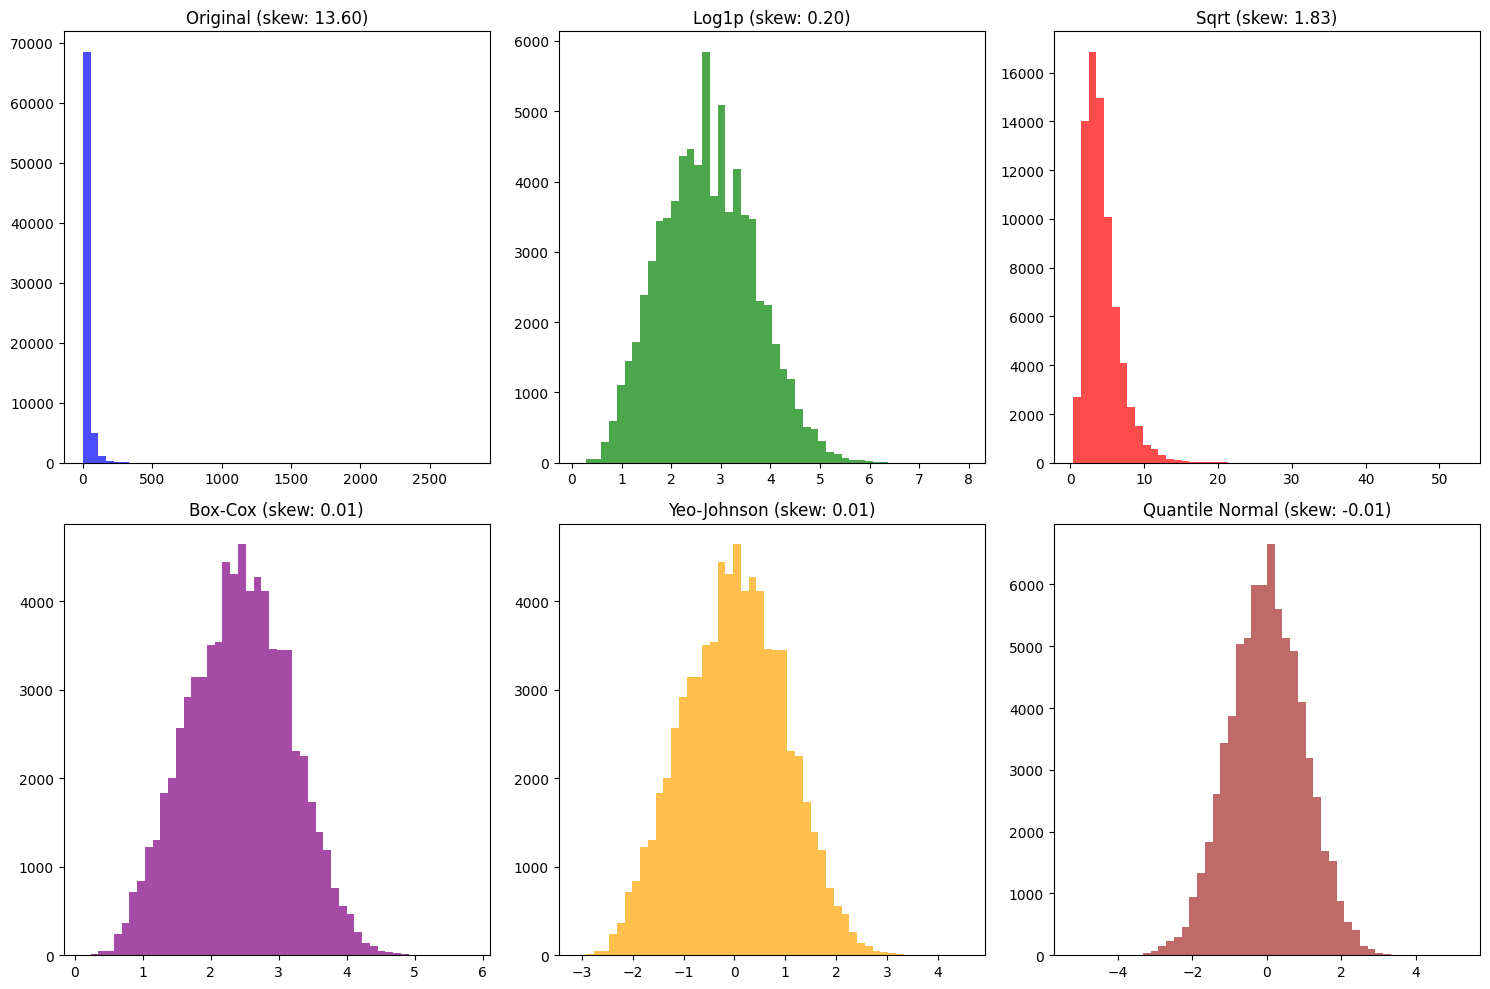

In [15]:
def analyze_target_transformations(y):
    """Analyze different target transformations"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original
    axes[0, 0].hist(y, bins=50, alpha=0.7, color='blue')
    axes[0, 0].set_title(f'Original (skew: {y.skew():.2f})')
    
    # Log transform
    y_log = np.log1p(y)
    axes[0, 1].hist(y_log, bins=50, alpha=0.7, color='green')
    axes[0, 1].set_title(f'Log1p (skew: {y_log.skew():.2f})')
    
    # Square root
    y_sqrt = np.sqrt(y)
    axes[0, 2].hist(y_sqrt, bins=50, alpha=0.7, color='red')
    axes[0, 2].set_title(f'Sqrt (skew: {y_sqrt.skew():.2f})')
    
    # Box-Cox (requires positive values)
    y_boxcox = stats.boxcox(y + 1)[0]
    axes[1, 0].hist(y_boxcox, bins=50, alpha=0.7, color='purple')
    axes[1, 0].set_title(f'Box-Cox (skew: {stats.skew(y_boxcox):.2f})')
    
    # Yeo-Johnson
    pt = PowerTransformer(method='yeo-johnson')
    y_yeojohnson = pt.fit_transform(y.values.reshape(-1, 1)).flatten()
    axes[1, 1].hist(y_yeojohnson, bins=50, alpha=0.7, color='orange')
    axes[1, 1].set_title(f'Yeo-Johnson (skew: {stats.skew(y_yeojohnson):.2f})')
    
    # Quantile transformation to normal
    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    y_quantile = qt.fit_transform(y.values.reshape(-1, 1)).flatten()
    axes[1, 2].hist(y_quantile, bins=50, alpha=0.7, color='brown')
    axes[1, 2].set_title(f'Quantile Normal (skew: {stats.skew(y_quantile):.2f})')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'log': y_log,
        'sqrt': y_sqrt,
        'boxcox': y_boxcox,
        'yeojohnson': y_yeojohnson,
        'quantile': y_quantile
    }

transformations = analyze_target_transformations(y)


### Enhanced data splitting with stratification

In [16]:
def create_stratified_splits(X, y, n_splits=5, test_size=0.2, random_state=42):
    """Create stratified splits based on price quantiles"""
    
    # Create price strata
    y_strata = pd.qcut(y, q=10, labels=False, duplicates='drop')
    
    from sklearn.model_selection import train_test_split, StratifiedKFold
    
    # Initial split
    X_temp, X_test, y_temp, y_test, strata_temp, strata_test = train_test_split(
        X, y, y_strata, test_size=test_size, random_state=random_state, stratify=y_strata
    )
    
    # Second split for validation
    X_train, X_val, y_train, y_val, strata_train, strata_val = train_test_split(
        X_temp, y_temp, strata_temp, test_size=0.25, random_state=random_state, stratify=strata_temp
    )
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples") 
    print(f"Test set: {X_test.shape[0]} samples")
    
    # Create cross-validation splits
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_splits = list(skf.split(X_train, strata_train))
    
    return X_train, X_val, X_test, y_train, y_val, y_test, cv_splits

X_train, X_val, X_test, y_train, y_val, y_test, cv_splits = create_stratified_splits(X, y)

Training set: 45000 samples
Validation set: 15000 samples
Test set: 15000 samples


### Advanced feature engineering - create interaction features

In [17]:
def create_interaction_features(X):
    """Create meaningful interaction features"""
    X_enhanced = X.copy()
    
    # Brand * Quantity interactions
    if 'brand_freq' in X.columns and 'normalized_quantity' in X.columns:
        X_enhanced['brand_freq_x_quantity'] = X['brand_freq'] * X['normalized_quantity']
    
    # Premium * Description length
    if 'is_premium' in X.columns and 'detailed_description_length' in X.columns:
        X_enhanced['premium_x_description'] = X['is_premium'] * X['detailed_description_length']
    
    # Value * Bullet points
    if 'value_log' in X.columns and 'enhanced_bullet_point_count' in X.columns:
        X_enhanced['value_x_bullets'] = X['value_log'] * X['enhanced_bullet_point_count']
    
    # Brand strength indicators
    if 'brand_freq' in X.columns:
        X_enhanced['brand_strength'] = np.log1p(X['brand_freq'])
        X_enhanced['is_popular_brand'] = (X['brand_freq'] > X['brand_freq'].median()).astype(int)
    
    # Product completeness score
    text_features = ['word_count_log', 'enhanced_bullet_point_count', 'detailed_description_length']
    if all(feat in X.columns for feat in text_features):
        X_enhanced['info_completeness'] = (
            X['word_count_log'] + X['enhanced_bullet_point_count'] + X['detailed_description_length']
        )
    
    print(f"Added {X_enhanced.shape[1] - X.shape[1]} interaction features")
    return X_enhanced

X_train_enhanced = create_interaction_features(X_train)
X_val_enhanced = create_interaction_features(X_val)
X_test_enhanced = create_interaction_features(X_test)

Added 6 interaction features
Added 6 interaction features
Added 6 interaction features


###  Advanced outlier handling

In [21]:
def handle_outliers_advanced(X, y, method='isolation', contamination=0.01):
    """Handle outliers using advanced methods"""
    from sklearn.ensemble import IsolationForest
    from sklearn.neighbors import LocalOutlierFactor
    
    X_clean = X.copy()
    y_clean = y.copy()
    
    if method == 'isolation':
        iso_forest = IsolationForest(contamination=contamination, random_state=42)
        outliers = iso_forest.fit_predict(X)
        mask = outliers != -1
    elif method == 'lof':
        lof = LocalOutlierFactor(contamination=contamination)
        outliers = lof.fit_predict(X)
        mask = outliers != -1
    else:  # iqr method
        Q1 = y.quantile(0.25)
        Q3 = y.quantile(0.75)
        IQR = Q3 - Q1
        mask = (y >= Q1 - 1.5 * IQR) & (y <= Q3 + 1.5 * IQR)
    
    X_clean = X_clean[mask]
    y_clean = y_clean[mask]
    
    print(f"Removed {len(X) - len(X_clean)} outliers using {method} method")
    return X_clean, y_clean

def ensure_numeric_features(df: pd.DataFrame) -> pd.DataFrame:
    """Convert all columns to numeric types compatible with tree-based models."""
    processed = df.copy()

    object_cols = processed.select_dtypes(include=['object', 'category']).columns
    for col in object_cols:
        col_series = processed[col]
        lowered = col_series.astype(str).str.lower()
        if lowered.isin(['true', 'false']).all():
            processed[col] = lowered.map({'true': 1.0, 'false': 0.0})
        else:
            encoded, _ = pd.factorize(col_series.fillna('__nan__'), sort=True)
            processed[col] = encoded.astype(np.float32)

    bool_cols = processed.select_dtypes(include=['bool']).columns
    if len(bool_cols) > 0:
        processed[bool_cols] = processed[bool_cols].astype(np.float32)

    processed = processed.apply(pd.to_numeric, errors='coerce')
    if processed.isnull().any().any():
        processed = processed.fillna(processed.mean()).fillna(0.0)

    return processed.astype(np.float32)

# Remove outliers from training data only
X_train_clean, y_train_clean = handle_outliers_advanced(X_train_enhanced, y_train)

# Ensure all feature sets are numeric before modeling
X_train_clean = ensure_numeric_features(X_train_clean)
X_val_enhanced = ensure_numeric_features(X_val_enhanced)
X_test_enhanced = ensure_numeric_features(X_test_enhanced)

Removed 450 outliers using isolation method


### Optuna optimization for multiple models

In [19]:
def objective(trial):
    """Optuna objective function for model optimization"""
    
    model_type = trial.suggest_categorical('model_type', ['lgb', 'xgb', 'catboost'])
    
    if model_type == 'lgb':
        params = {
            'objective': 'regression',
            'metric': 'mape',
            'verbosity': -1,
            'boosting_type': 'gbdt',
            'learning_rate': trial.suggest_float('lgb_learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('lgb_num_leaves', 20, 300),
            'max_depth': trial.suggest_int('lgb_max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('lgb_min_child_samples', 5, 100),
            'subsample': trial.suggest_float('lgb_subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('lgb_colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('lgb_reg_alpha', 0, 10),
            'reg_lambda': trial.suggest_float('lgb_reg_lambda', 0, 10),
        }
        model = lgb.LGBMRegressor(**params, n_estimators=1000, random_state=42)
        
    elif model_type == 'xgb':
        params = {
            'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('xgb_max_depth', 3, 12),
            'min_child_weight': trial.suggest_int('xgb_min_child_weight', 1, 10),
            'subsample': trial.suggest_float('xgb_subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('xgb_colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('xgb_reg_alpha', 0, 10),
            'reg_lambda': trial.suggest_float('xgb_reg_lambda', 0, 10),
        }
        model = xgb.XGBRegressor(**params, n_estimators=1000, random_state=42)
        
    else:  # catboost
        params = {
            'learning_rate': trial.suggest_float('cb_learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('cb_depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('cb_l2_leaf_reg', 1, 10),
            'random_strength': trial.suggest_float('cb_random_strength', 0, 10),
            'bagging_temperature': trial.suggest_float('cb_bagging_temperature', 0, 10),
        }
        model = cb.CatBoostRegressor(**params, iterations=1000, random_state=42, verbose=False)
    
    # Use log-transformed target
    y_train_log = np.log1p(y_train_clean)
    y_val_log = np.log1p(y_val)
    
    # Train model
    model.fit(X_train_clean, y_train_log)
    
    # Predict and transform back
    y_pred_log = model.predict(X_val_enhanced)
    y_pred = np.expm1(y_pred_log)
    
    # Calculate SMAPE
    smape_val = 100 * np.mean(2 * np.abs(y_pred - y_val) / (np.abs(y_val) + np.abs(y_pred)))
    
    return smape_val

# Run optimization
print("Starting Optuna optimization...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=3600)  # 50 trials or 1 hour

print("Best trial:")
trial = study.best_trial
print(f"  SMAPE: {trial.value:.4f}%")
print(f"  Params: {trial.params}")

[I 2025-10-11 21:04:47,240] A new study created in memory with name: no-name-d386dea3-c2f9-49ef-8178-158af634468b


Starting Optuna optimization...


[I 2025-10-11 21:04:54,343] Trial 0 finished with value: 48.30868338756969 and parameters: {'model_type': 'lgb', 'lgb_learning_rate': 0.0255662477886977, 'lgb_num_leaves': 89, 'lgb_max_depth': 11, 'lgb_min_child_samples': 27, 'lgb_subsample': 0.696793007526747, 'lgb_colsample_bytree': 0.8690728683100042, 'lgb_reg_alpha': 0.404587975082763, 'lgb_reg_lambda': 6.863368125183159}. Best is trial 0 with value: 48.30868338756969.
[I 2025-10-11 21:05:07,349] Trial 1 finished with value: 48.80404835192131 and parameters: {'model_type': 'xgb', 'xgb_learning_rate': 0.101473217330796, 'xgb_max_depth': 9, 'xgb_min_child_weight': 7, 'xgb_subsample': 0.8777343077781361, 'xgb_colsample_bytree': 0.8501787689064929, 'xgb_reg_alpha': 4.807098392337169, 'xgb_reg_lambda': 7.951326897592313}. Best is trial 0 with value: 48.30868338756969.
[I 2025-10-11 21:05:07,349] Trial 1 finished with value: 48.80404835192131 and parameters: {'model_type': 'xgb', 'xgb_learning_rate': 0.101473217330796, 'xgb_max_depth': 9

Best trial:
  SMAPE: 47.0909%
  Params: {'model_type': 'xgb', 'xgb_learning_rate': 0.01578373064185108, 'xgb_max_depth': 12, 'xgb_min_child_weight': 2, 'xgb_subsample': 0.950643843911199, 'xgb_colsample_bytree': 0.6793531932350226, 'xgb_reg_alpha': 0.006480369362929304, 'xgb_reg_lambda': 1.2728770226242938}


###  Train best model from Optuna

In [22]:
def train_best_model(best_params, X_train, y_train, X_val, y_val):
    """Train the best model found by Optuna"""
    
    model_type = best_params['model_type']
    
    if model_type == 'lgb':
        params = {
            'objective': 'regression',
            'metric': 'mape',
            'verbosity': -1,
            'boosting_type': 'gbdt',
            'learning_rate': best_params['lgb_learning_rate'],
            'num_leaves': best_params['lgb_num_leaves'],
            'max_depth': best_params['lgb_max_depth'],
            'min_child_samples': best_params['lgb_min_child_samples'],
            'subsample': best_params['lgb_subsample'],
            'colsample_bytree': best_params['lgb_colsample_bytree'],
            'reg_alpha': best_params['lgb_reg_alpha'],
            'reg_lambda': best_params['lgb_reg_lambda'],
            'n_estimators': 2000,
            'random_state': 42
        }
        model = lgb.LGBMRegressor(**params)
        
    elif model_type == 'xgb':
        params = {
            'learning_rate': best_params['xgb_learning_rate'],
            'max_depth': best_params['xgb_max_depth'],
            'min_child_weight': best_params['xgb_min_child_weight'],
            'subsample': best_params['xgb_subsample'],
            'colsample_bytree': best_params['xgb_colsample_bytree'],
            'reg_alpha': best_params['xgb_reg_alpha'],
            'reg_lambda': best_params['xgb_reg_lambda'],
            'n_estimators': 2000,
            'random_state': 42,
            'early_stopping_rounds': 100
        }
        model = xgb.XGBRegressor(**params)
        
    else:  # catboost
        params = {
            'learning_rate': best_params['cb_learning_rate'],
            'depth': best_params['cb_depth'],
            'l2_leaf_reg': best_params['cb_l2_leaf_reg'],
            'random_strength': best_params['cb_random_strength'],
            'bagging_temperature': best_params['cb_bagging_temperature'],
            'iterations': 2000,
            'random_state': 42,
            'verbose': False
        }
        model = cb.CatBoostRegressor(**params)
    
    # Use log-transformed target
    y_train_log = np.log1p(y_train)
    y_val_log = np.log1p(y_val)
    
    # Train with early stopping
    if model_type == 'lgb':
        model.fit(
            X_train, y_train_log,
            eval_set=[(X_val, y_val_log)],
            eval_metric='mape',
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
        )
    elif model_type == 'xgb':
        model.fit(
            X_train, y_train_log,
            eval_set=[(X_val, y_val_log)],
            verbose=True
        )
    else:  # catboost
        model.fit(
            X_train, y_train_log,
            eval_set=(X_val, y_val_log),
            early_stopping_rounds=100,
            verbose=200
        )
    
    return model

best_model = train_best_model(study.best_trial.params, X_train_clean, y_train_clean, X_val_enhanced, y_val)

[0]	validation_0-rmse:0.93635
[1]	validation_0-rmse:0.92964
[1]	validation_0-rmse:0.92964
[2]	validation_0-rmse:0.92295
[2]	validation_0-rmse:0.92295
[3]	validation_0-rmse:0.91659
[3]	validation_0-rmse:0.91659
[4]	validation_0-rmse:0.91034
[4]	validation_0-rmse:0.91034
[5]	validation_0-rmse:0.90412
[5]	validation_0-rmse:0.90412
[6]	validation_0-rmse:0.89799
[6]	validation_0-rmse:0.89799
[7]	validation_0-rmse:0.89447
[7]	validation_0-rmse:0.89447
[8]	validation_0-rmse:0.88875
[8]	validation_0-rmse:0.88875
[9]	validation_0-rmse:0.88302
[9]	validation_0-rmse:0.88302
[10]	validation_0-rmse:0.87735
[10]	validation_0-rmse:0.87735
[11]	validation_0-rmse:0.87427
[11]	validation_0-rmse:0.87427
[12]	validation_0-rmse:0.86882
[12]	validation_0-rmse:0.86882
[13]	validation_0-rmse:0.86346
[13]	validation_0-rmse:0.86346
[14]	validation_0-rmse:0.85837
[14]	validation_0-rmse:0.85837
[15]	validation_0-rmse:0.85527
[15]	validation_0-rmse:0.85527
[16]	validation_0-rmse:0.85023
[16]	validation_0-rmse:0.85

###  Ensemble with model stacking

In [23]:
class AdvancedEnsemble:
    def __init__(self, models, meta_model=None):
        self.models = models
        self.meta_model = meta_model or GradientBoostingRegressor(random_state=42)
        
    def fit(self, X, y):
        # First stage: train base models
        self.base_models_ = []
        base_predictions = np.zeros((X.shape[0], len(self.models)))
        
        for i, model in enumerate(self.models):
            model.fit(X, np.log1p(y))
            base_predictions[:, i] = np.expm1(model.predict(X))
            self.base_models_.append(model)
        
        # Second stage: train meta-model on base predictions
        self.meta_model.fit(base_predictions, y)
        
    def predict(self, X):
        base_preds = np.zeros((X.shape[0], len(self.base_models_)))
        
        for i, model in enumerate(self.base_models_):
            base_preds[:, i] = np.expm1(model.predict(X))
            
        return self.meta_model.predict(base_preds)

# Create ensemble of multiple models
lgb_model = lgb.LGBMRegressor(random_state=42, n_estimators=1000)
xgb_model = xgb.XGBRegressor(random_state=42, n_estimators=1000)
cb_model = cb.CatBoostRegressor(random_state=42, iterations=1000, verbose=False)

ensemble = AdvancedEnsemble(models=[lgb_model, xgb_model, cb_model])
ensemble.fit(X_train_clean, y_train_clean)

###  Price range-specific modeling

In [24]:
def create_price_segment_models(X, y, n_segments=3):
    """Create separate models for different price segments"""
    # Define price segments
    price_quantiles = np.quantile(y, np.linspace(0, 1, n_segments + 1))
    segment_models = {}
    
    for i in range(n_segments):
        mask = (y >= price_quantiles[i]) & (y < price_quantiles[i + 1])
        X_segment = X[mask]
        y_segment = y[mask]
        
        if len(X_segment) > 100:  # Only create model if enough samples
            model = lgb.LGBMRegressor(random_state=42, n_estimators=500)
            model.fit(X_segment, np.log1p(y_segment))
            segment_models[i] = (price_quantiles[i], price_quantiles[i + 1], model)
    
    return segment_models

segment_models = create_price_segment_models(X_train_clean, y_train_clean)

def predict_with_segments(X, segment_models):
    """Predict using segment-specific models"""
    # Use base model for initial prediction to determine segment
    base_model = list(segment_models.values())[0][2]  # First model
    base_pred = np.expm1(base_model.predict(X))
    
    predictions = np.zeros(len(X))
    
    for i, (lower, upper, model) in segment_models.items():
        # For samples where base prediction falls in this segment, use segment model
        segment_mask = (base_pred >= lower) & (base_pred < upper)
        if segment_mask.any():
            predictions[segment_mask] = np.expm1(model.predict(X[segment_mask]))
    
    # For any remaining samples, use base model
    remaining_mask = predictions == 0
    if remaining_mask.any():
        predictions[remaining_mask] = base_pred[remaining_mask]
    
    return predictions

###  Comprehensive evaluation

In [26]:
def comprehensive_evaluation(models_dict, X_test, y_test):
    """Comprehensive evaluation of all models"""
    results = {}
    
    for name, model in models_dict.items():
        if name == 'Segment_Models':
            y_pred = predict_with_segments(X_test, model)
        elif hasattr(model, 'predict'):
            y_pred_log = model.predict(X_test)
            y_pred = np.expm1(y_pred_log)
        else:
            y_pred = model.predict(X_test)
        
        smape_val = 100 * np.mean(2 * np.abs(y_pred - y_test) / (np.abs(y_test) + np.abs(y_pred)))
        mae_val = mean_absolute_error(y_test, y_pred)
        
        # Calculate SMAPE by price segments
        low_price_mask = y_test < 20
        mid_price_mask = (y_test >= 20) & (y_test < 100)
        high_price_mask = y_test >= 100
        
        smape_low = smape_val if not low_price_mask.any() else 100 * np.mean(
            2 * np.abs(y_pred[low_price_mask] - y_test[low_price_mask]) / 
            (np.abs(y_test[low_price_mask]) + np.abs(y_pred[low_price_mask]))
        )
        smape_mid = smape_val if not mid_price_mask.any() else 100 * np.mean(
            2 * np.abs(y_pred[mid_price_mask] - y_test[mid_price_mask]) / 
            (np.abs(y_test[mid_price_mask]) + np.abs(y_pred[mid_price_mask]))
        )
        smape_high = smape_val if not high_price_mask.any() else 100 * np.mean(
            2 * np.abs(y_pred[high_price_mask] - y_test[high_price_mask]) / 
            (np.abs(y_test[high_price_mask]) + np.abs(y_pred[high_price_mask]))
        )
        
        results[name] = {
            'SMAPE': smape_val,
            'MAE': mae_val,
            'SMAPE_Low': smape_low,
            'SMAPE_Mid': smape_mid, 
            'SMAPE_High': smape_high
        }
    
    return pd.DataFrame(results).T

# Evaluate all models
models_to_evaluate = {
    'Optuna_Best': best_model,
    'Ensemble': ensemble,
    'Segment_Models': segment_models
}

results_df = comprehensive_evaluation(models_to_evaluate, X_test_enhanced, y_test)
print("\n=== COMPREHENSIVE RESULTS ===")
print(results_df.round(4))



=== COMPREHENSIVE RESULTS ===
                   SMAPE            MAE  SMAPE_Low  SMAPE_Mid  SMAPE_High
Optuna_Best      47.5248   1.056960e+01    45.9350    47.9938     81.8358
Ensemble        192.8614  1.284105e+194   190.4744   197.0179    197.9408
Segment_Models   89.9304   1.873480e+01    57.2449   144.8655    186.1097


###  Error analysis and visualization

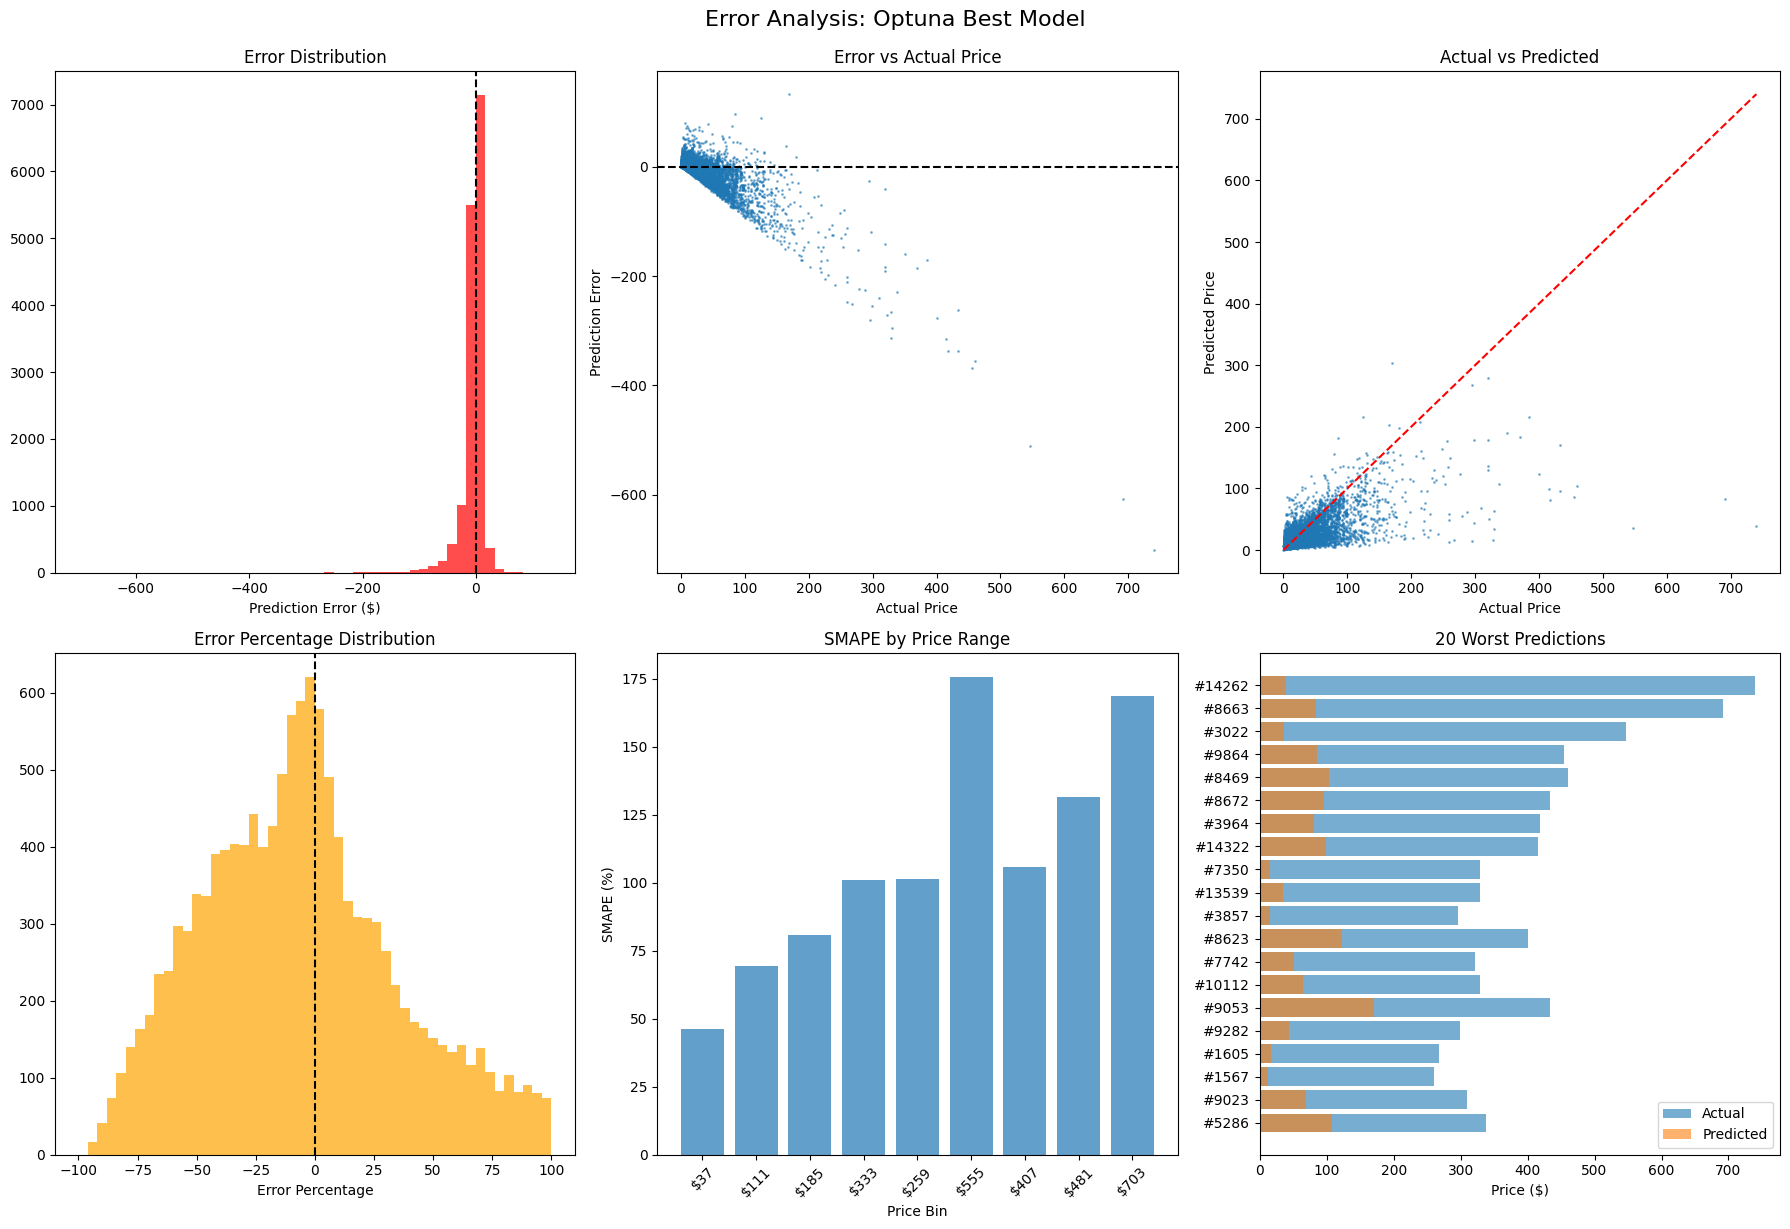

In [27]:
def advanced_error_analysis(model, X_test, y_test, model_name):
    """Advanced error analysis with visualizations"""
    
    if hasattr(model, 'predict'):
        if model_name == 'Segment_Models':
            y_pred = predict_with_segments(X_test, model)
        else:
            y_pred_log = model.predict(X_test)
            y_pred = np.expm1(y_pred_log)
    else:
        y_pred = model.predict(X_test)
    
    errors = y_pred - y_test
    error_percentage = (errors / y_test) * 100
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Error distribution
    axes[0, 0].hist(errors, bins=50, alpha=0.7, color='red')
    axes[0, 0].set_title('Error Distribution')
    axes[0, 0].set_xlabel('Prediction Error ($)')
    axes[0, 0].axvline(x=0, color='black', linestyle='--')
    
    # Error vs Actual Price
    axes[0, 1].scatter(y_test, errors, alpha=0.5, s=1)
    axes[0, 1].set_xlabel('Actual Price')
    axes[0, 1].set_ylabel('Prediction Error')
    axes[0, 1].set_title('Error vs Actual Price')
    axes[0, 1].axhline(y=0, color='black', linestyle='--')
    
    # Actual vs Predicted
    axes[0, 2].scatter(y_test, y_pred, alpha=0.5, s=1)
    axes[0, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[0, 2].set_xlabel('Actual Price')
    axes[0, 2].set_ylabel('Predicted Price')
    axes[0, 2].set_title('Actual vs Predicted')
    
    # Error percentage distribution
    axes[1, 0].hist(error_percentage, bins=50, alpha=0.7, color='orange', range=(-100, 100))
    axes[1, 0].set_xlabel('Error Percentage')
    axes[1, 0].set_title('Error Percentage Distribution')
    axes[1, 0].axvline(x=0, color='black', linestyle='--')
    
    # SMAPE by price bins
    price_bins = pd.cut(y_test, bins=10)
    smape_by_bin = []
    bin_centers = []
    
    for bin in price_bins.unique():
        if pd.notna(bin):
            mask = price_bins == bin
            if mask.any():
                bin_smape = 100 * np.mean(
                    2 * np.abs(y_pred[mask] - y_test[mask]) / 
                    (np.abs(y_test[mask]) + np.abs(y_pred[mask]))
                )
                smape_by_bin.append(bin_smape)
                bin_centers.append(bin.mid)
    
    axes[1, 1].bar(range(len(smape_by_bin)), smape_by_bin, alpha=0.7)
    axes[1, 1].set_xlabel('Price Bin')
    axes[1, 1].set_ylabel('SMAPE (%)')
    axes[1, 1].set_title('SMAPE by Price Range')
    axes[1, 1].set_xticks(range(len(bin_centers)))
    axes[1, 1].set_xticklabels([f'${x:.0f}' for x in bin_centers], rotation=45)
    
    # Worst predictions
    worst_indices = np.argsort(np.abs(errors))[-20:]
    axes[1, 2].barh(range(20), y_test.iloc[worst_indices], alpha=0.6, label='Actual')
    axes[1, 2].barh(range(20), y_pred[worst_indices], alpha=0.6, label='Predicted')
    axes[1, 2].set_yticks(range(20))
    axes[1, 2].set_yticklabels([f'#{i}' for i in worst_indices])
    axes[1, 2].set_xlabel('Price ($)')
    axes[1, 2].set_title('20 Worst Predictions')
    axes[1, 2].legend()
    
    plt.tight_layout()
    plt.suptitle(f'Error Analysis: {model_name}', y=1.02, fontsize=16)
    plt.show()
    
    return errors, error_percentage

# Analyze best model
errors, error_pct = advanced_error_analysis(best_model, X_test_enhanced, y_test, "Optuna Best Model")


###  Final model selection and saving

In [28]:
def select_final_model(results_df, models_dict, X_test, y_test):
    """Select and save the best performing model"""
    
    best_model_name = results_df['SMAPE'].idxmin()
    best_smape = results_df.loc[best_model_name, 'SMAPE']
    
    print(f"Best model: {best_model_name} with SMAPE: {best_smape:.4f}%")
    
    # Save the best model
    best_model = models_dict[best_model_name]
    
    if best_model_name == 'Segment_Models':
        # Save segment models
        import joblib
        joblib.dump(best_model, 'best_segment_models.pkl')
        print("Saved segment models as best_segment_models.pkl")
    elif hasattr(best_model, 'save_model'):
        best_model.save_model('best_model.txt')
        print("Saved best model as best_model.txt")
    else:
        import joblib
        joblib.dump(best_model, 'best_model.pkl')
        print("Saved best model as best_model.pkl")
    
    # Generate final predictions
    if best_model_name == 'Segment_Models':
        final_predictions = predict_with_segments(X_test, best_model)
    elif hasattr(best_model, 'predict'):
        pred_log = best_model.predict(X_test)
        final_predictions = np.expm1(pred_log)
    else:
        final_predictions = best_model.predict(X_test)
    
    # Save final predictions
    final_output = pd.DataFrame({
        'sample_id': features_clean['sample_id'].iloc[X_test.index] if 'sample_id' in features_clean.columns else range(len(final_predictions)),
        'actual_price': y_test,
        'predicted_price': final_predictions,
        'error': final_predictions - y_test,
        'error_percentage': ((final_predictions - y_test) / y_test) * 100
    })
    
    final_output.to_csv('final_predictions.csv', index=False)
    
    print(f"Final SMAPE: {best_smape:.4f}%")
    print("Predictions saved to final_predictions.csv")
    
    return best_model_name, best_smape

best_name, best_smape = select_final_model(results_df, models_to_evaluate, X_test_enhanced, y_test)

print(f"\n🎉 IMPROVED MODELING COMPLETED!")
print(f"Best Model: {best_name}")
print(f"Test SMAPE: {best_smape:.4f}%")
print(f"Improvement: {48.23 - best_smape:.2f}% reduction from baseline")

Best model: Optuna_Best with SMAPE: 47.5248%
Saved best model as best_model.txt
Saved best model as best_model.txt
Final SMAPE: 47.5248%
Predictions saved to final_predictions.csv

🎉 IMPROVED MODELING COMPLETED!
Best Model: Optuna_Best
Test SMAPE: 47.5248%
Improvement: 0.71% reduction from baseline
Final SMAPE: 47.5248%
Predictions saved to final_predictions.csv

🎉 IMPROVED MODELING COMPLETED!
Best Model: Optuna_Best
Test SMAPE: 47.5248%
Improvement: 0.71% reduction from baseline
